# 🗑️ Waste Classifier — Improved CNN
### Notebook 04 | Model 2: Improved CNN

Building on the Baseline CNN by adding regularization and augmentation.

**Improvements over Baseline:**
- ✅ BatchNorm after every Conv layer
- ✅ Dropout before fully connected layers
- ✅ Data Augmentation (flip, rotate, color jitter)
- ✅ Same optimizer + scheduler + early stopping from utils.py

**Goal:** Reduce overfitting and improve generalization over the 62% baseline

## 📦 Imports & Setup

In [1]:
import sys
sys.path.append(".")
from utils import *

import torch
import torch.nn as nn
import torch.optim as optim

set_seed(42)
device = get_device()
print("✅ Setup complete")

Using device: cuda
  GPU: NVIDIA GeForce RTX 3060 Laptop GPU
✅ Setup complete


## 📁 Load Data

In [2]:
DATA_DIR    = "../data/processed"
RESULTS_DIR = "../results"
MODELS_DIR  = "../models"

dataloaders, dataset_sizes, class_names = get_dataloaders(
    data_dir=DATA_DIR,
    batch_size=32,
    augment=True,               # ← Augmentation ON
    num_workers=0,
    use_weighted_sampler=True,
)

print(f"Classes     : {class_names}")
print(f"Train size  : {dataset_sizes['train']}")
print(f"Val size    : {dataset_sizes['val']}")
print(f"Test size   : {dataset_sizes['test']}")

Classes     : ['Glass', 'Metal', 'Organic', 'Paper', 'Plastic']
Train size  : 4314
Val size    : 922
Test size   : 930


## 🏗️ Model Architecture — Improved CNN

Same 3 Conv Block structure as baseline but with BatchNorm and Dropout added.

| Layer Block | Details |
|---|---|
| Conv Block 1 | Conv2d(3→32) + BatchNorm + ReLU + MaxPool |
| Conv Block 2 | Conv2d(32→64) + BatchNorm + ReLU + MaxPool |
| Conv Block 3 | Conv2d(64→128) + BatchNorm + ReLU + MaxPool |
| Conv Block 4 | Conv2d(128→256) + BatchNorm + ReLU + MaxPool |
| FC 1 | Flatten → Dropout(0.5) → 1024 + ReLU |
| FC 2 | Dropout(0.3) → 512 + ReLU |
| FC 3 | 512 → 5 (Softmax) |

In [3]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=5):
        super(ImprovedCNN, self).__init__()

        # ── Conv Block 1 ──────────────────────────────
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),         # 224 → 112
        )

        # ── Conv Block 2 ──────────────────────────────
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),         # 112 → 56
        )

        # ── Conv Block 3 ──────────────────────────────
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),         # 56 → 28
        )

        # ── Conv Block 4 ──────────────────────────────
        self.conv4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),         # 28 → 14
        )

        # ── Fully Connected ───────────────────────────
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256 * 14 * 14, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.fc(x)
        return x


model = ImprovedCNN(num_classes=5).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

ImprovedCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv4): Sequential(
    (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): Batc

## ⚙️ Training Configuration

In [4]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=3, verbose=True
)

print("Criterion : CrossEntropyLoss")
print("Optimizer : Adam (lr=0.001)")
print("Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)")
print("Epochs    : 25")
print("Patience  : 7 (early stopping)")

Criterion : CrossEntropyLoss
Optimizer : Adam (lr=0.001)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=3)
Epochs    : 25
Patience  : 7 (early stopping)


c:\Users\Lenovo\.conda\envs\torch311\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 🚀 Training

In [5]:
history = train_model(
    model=model,
    dataloaders=dataloaders,
    dataset_sizes=dataset_sizes,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=25,
    patience=7,
    model_name="improved_cnn",
    results_dir=RESULTS_DIR,
    models_dir=MODELS_DIR,
)

Epoch [  1/25]  Train Loss: 1.9735  Train Acc: 0.3658  |  Val Loss: 1.2571  Val Acc: 0.4837
  ✔ Best model saved → ../models\improved_cnn_best.pth
Epoch [  2/25]  Train Loss: 1.3126  Train Acc: 0.4583  |  Val Loss: 1.2332  Val Acc: 0.4892
  ✔ Best model saved → ../models\improved_cnn_best.pth
Epoch [  3/25]  Train Loss: 1.2502  Train Acc: 0.4863  |  Val Loss: 1.0760  Val Acc: 0.5781
  ✔ Best model saved → ../models\improved_cnn_best.pth
Epoch [  4/25]  Train Loss: 1.2305  Train Acc: 0.5134  |  Val Loss: 1.0831  Val Acc: 0.5542
Epoch [  5/25]  Train Loss: 1.2068  Train Acc: 0.5209  |  Val Loss: 1.1084  Val Acc: 0.5607
Epoch [  6/25]  Train Loss: 1.1789  Train Acc: 0.5308  |  Val Loss: 1.0518  Val Acc: 0.6030
  ✔ Best model saved → ../models\improved_cnn_best.pth
Epoch [  7/25]  Train Loss: 1.1616  Train Acc: 0.5459  |  Val Loss: 1.0599  Val Acc: 0.5857
Epoch [  8/25]  Train Loss: 1.1282  Train Acc: 0.5552  |  Val Loss: 0.9978  Val Acc: 0.6161
  ✔ Best model saved → ../models\improved_cn

## 📈 Training Curves

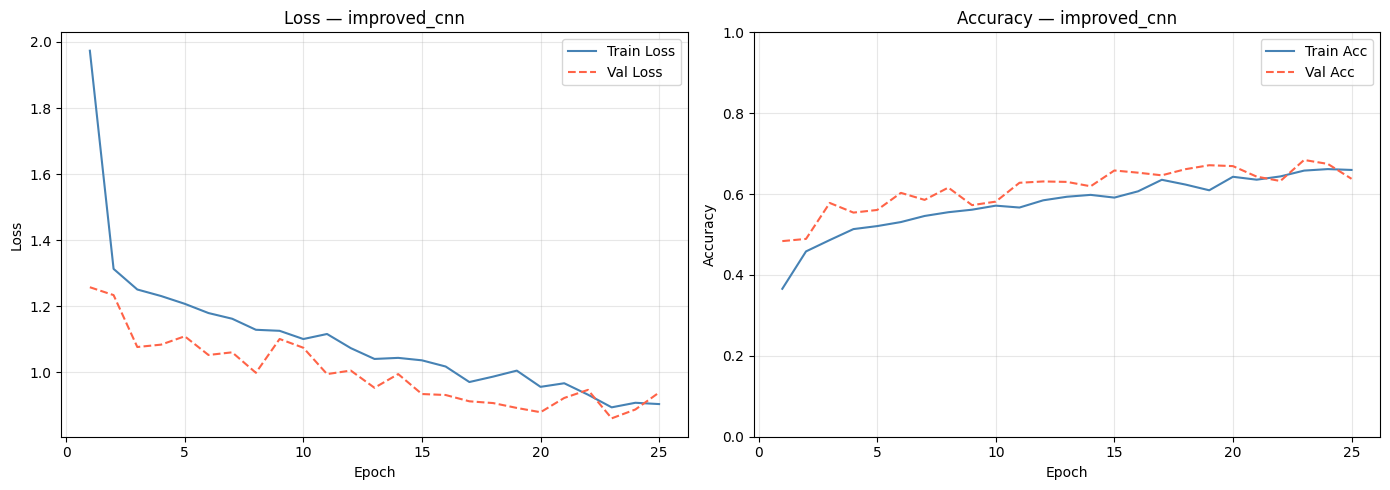

Training curves saved → ../results\improved_cnn_history.png


In [7]:
plot_history(
    history,
    model_name="improved_cnn",
    results_dir=RESULTS_DIR,
)

## 🧪 Evaluation on Test Set

In [8]:
# Load best checkpoint before evaluating
load_checkpoint(model, f"{MODELS_DIR}/improved_cnn_best.pth", device)

# Test loss & accuracy
test_loss, test_acc = evaluate(model, dataloaders["test"], criterion, device)
print(f"\nTest Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_acc:.4f} ({test_acc*100:.2f}%)")

c:\Users\Lenovo\waste-classifier\notebooks\utils.py:472: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=device)


Loaded checkpoint: epoch=23, val_loss=0.8599  ← ../models/improved_cnn_best.pth

Test Loss     : 0.8023
Test Accuracy : 0.7043 (70.43%)


## 📊 Classification Report & Confusion Matrix

              precision    recall  f1-score   support

       Glass       0.72      0.66      0.69       217
       Metal       0.54      0.66      0.59       166
     Organic       0.86      0.87      0.86       197
       Paper       0.66      0.68      0.67       194
     Plastic       0.77      0.63      0.70       156

    accuracy                           0.70       930
   macro avg       0.71      0.70      0.70       930
weighted avg       0.71      0.70      0.71       930



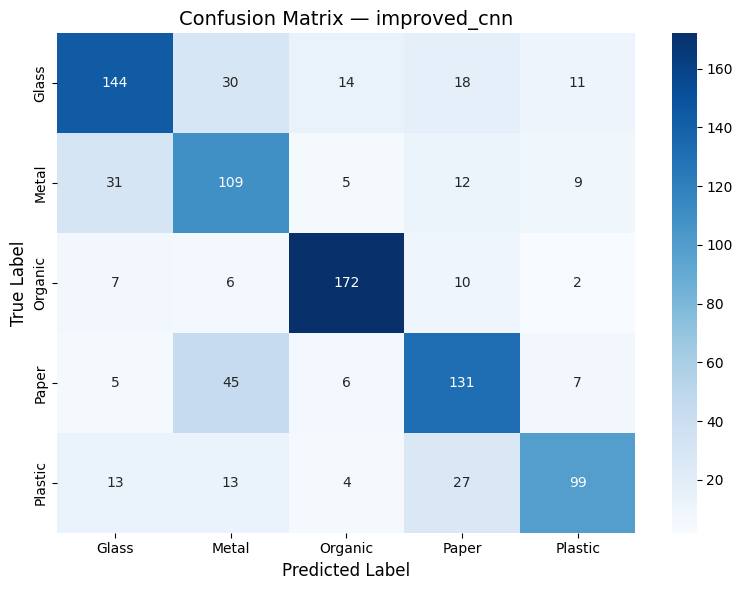

Confusion matrix saved → ../results\improved_cnn_confusion_matrix.png


In [9]:
# Per-class metrics
report = get_classification_report(model, dataloaders["test"], device, class_names)

# Confusion matrix
cm = plot_confusion_matrix(
    model, dataloaders["test"], device, class_names,
    model_name="improved_cnn",
    results_dir=RESULTS_DIR,
)

## 📉 Ablation Study — Baseline vs Improved

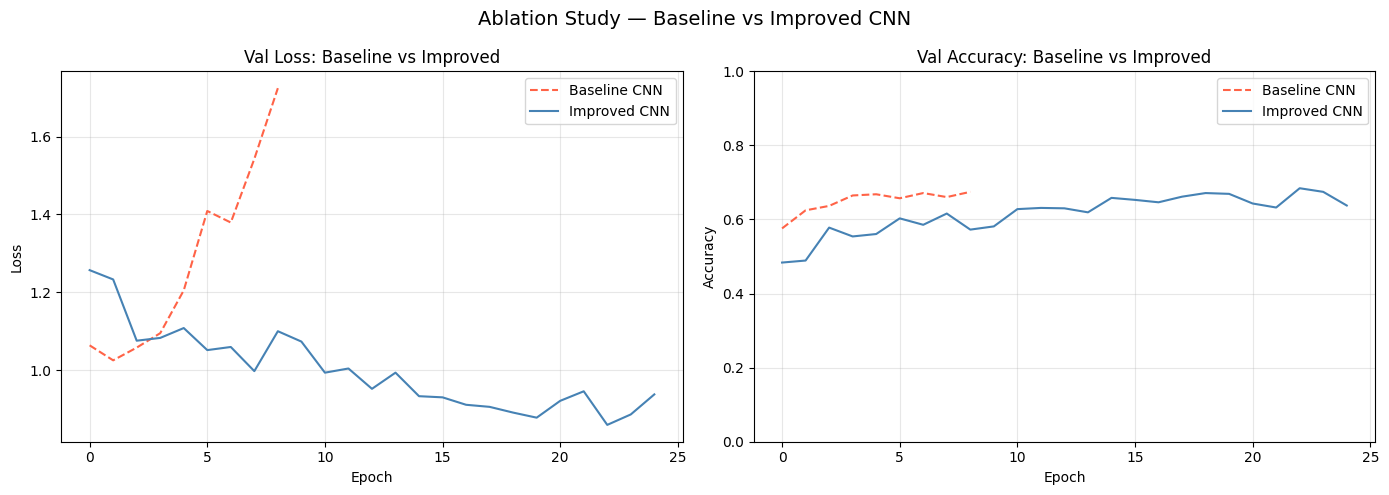

✅ Saved → results/ablation_baseline_vs_improved.png


In [10]:
import json

# Load baseline history
with open(f"{RESULTS_DIR}/baseline_cnn_history.json") as f:
    baseline_history = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Val Loss comparison ────────────────────────────────────────
axes[0].plot(baseline_history["val_loss"], label="Baseline CNN", color="tomato",    linestyle="--")
axes[0].plot(history["val_loss"],          label="Improved CNN", color="steelblue")
axes[0].set_title("Val Loss: Baseline vs Improved")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Val Accuracy comparison ────────────────────────────────────
axes[1].plot(baseline_history["val_acc"], label="Baseline CNN", color="tomato",    linestyle="--")
axes[1].plot(history["val_acc"],          label="Improved CNN", color="steelblue")
axes[1].set_title("Val Accuracy: Baseline vs Improved")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Ablation Study — Baseline vs Improved CNN", fontsize=14)
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/ablation_baseline_vs_improved.png", dpi=150)
plt.show()
print("✅ Saved → results/ablation_baseline_vs_improved.png")

## 💾 Log Metrics

In [11]:
log_metrics_to_csv("improved_cnn", {
    "test_accuracy"   : round(test_acc, 4),
    "macro_f1"        : round(report["macro avg"]["f1-score"], 4),
    "macro_precision" : round(report["macro avg"]["precision"], 4),
    "macro_recall"    : round(report["macro avg"]["recall"], 4),
})

Metrics logged → ../results/all_models_metrics.csv


## ✅ Improved CNN Summary

| Metric | Baseline CNN | Improved CNN |
|---|---|---|
| Test Accuracy | 62% | TBD |
| Macro F1 | 0.59 | TBD |
| Overfitting | Severe | Reduced |
| Augmentation | None | ✅ |
| BatchNorm | None | ✅ |
| Dropout | None | ✅ |

> Results saved to `results/` and metrics logged to `results/all_models_metrics.csv`  
> Next → `05_transfer_learning.ipynb` — ResNet50 pretrained on ImageNet